In [ ]:
import numpy as np
import os
from PIL import Image
import scipy
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
import torch.nn.functional as F
import torchvision.transforms as T
import io, base64
from tqdm.notebook import tqdm
from IPython.display import display, update_display
from matplotlib import  pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.graph_objs import FigureWidget
import plotly.express as px
import warnings
from google.colab import output
output.enable_custom_widget_manager()

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Модель GAN

In [ ]:
class Generator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.latent_dim = input_dim
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

### Модель DCGAN

In [ ]:
class Generator_DCGAN(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 256, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)


class Discriminator_DCGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
          nn.Conv2d(1, 64, kernel_size=3, stride=2, padding=1, bias=False),
          nn.BatchNorm2d(64),
          nn.LeakyReLU(0.2, True),
          nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
          nn.BatchNorm2d(128),
          nn.LeakyReLU(0.2, True),
          nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
          nn.BatchNorm2d(256),
          nn.LeakyReLU(0.2, True),
          nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0, bias=False),
          nn.Flatten(),
          nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


### Визуализация

In [ ]:
def create_plot_widget():
    # Виджет в plotly для вывода интерактивных графиков для обучения модели
    fig = make_subplots(rows=1, cols=3, shared_xaxes=False, horizontal_spacing=0.1, vertical_spacing=0.12,
                        subplot_titles=["Generator Loss", "Discriminator Loss", "Generated Images"],
                        specs=[
                          [{}, {}, {}]]
    )

    trace_gen_loss = go.Scatter(name="Generator BCELoss", line=dict(color="blue"), legendgroup=1)
    trace_discr_loss = go.Scatter(name="Discriminator BCELoss", line=dict(color="orange"), legendgroup=2)

    fig.add_trace(trace_gen_loss, row=1, col=1)
    fig.add_trace(trace_discr_loss, row=1, col=2)


    fig.update_layout(height=550, width=1500, title="GAN Training Progress",
                      xaxis1=dict(title="Epoch"), xaxis2=dict(title="Epoch"),
                      yaxis1=dict(title="Generator BCELoss"),
                      yaxis2=dict(title="Discriminator BCELoss"),
                      legend=dict(
                          orientation="h",
                          yanchor="bottom",
                          y=-0.3,
                          xanchor="center",
                          x=0.33
                      ),
                      xaxis3=dict(
                          range=[-1, 1],
                          zeroline=False,
                          showticklabels=False,
                          title=None,
                          showgrid=False,
                          fixedrange=True,
                      ),
                      yaxis3=dict(
                          range=[-1, 1],
                          zeroline=False,
                          showticklabels=False,
                          title=None,
                          showgrid=False,
                          fixedrange=True,
                          scaleanchor="x3",
                      ),
    )
    for i in range(1, 4):
        fig.update_layout({
            f"xaxis{i}": dict(title_standoff=5, automargin=True),
            f"yaxis{i}": dict(title_standoff=5, automargin=True, scaleanchor=f'x{i}', scaleratio=1)
        })

    fig.update_xaxes(showgrid=False, visible=False, row=1, col=3)
    fig.update_yaxes(showgrid=False, visible=False, row=1, col=3)

    fig.add_shape(
        type="rect",
        xref="paper", yref="paper",
        x0=0.7, x1=1.0,
        y0=0.0, y1=1.0,
        fillcolor="white",
        layer="below",
        line_width=0
    )

    fig_widget = FigureWidget(fig)
    return fig_widget

In [ ]:
def generate_sample(model, is_flatten=True, sample_size=64):
    # Генерация из латентного пространства
    model.eval()
    with torch.no_grad():
        if is_flatten:
            z = torch.randn(sample_size, model.latent_dim).to(device)
        else:
            z = torch.randn(sample_size, model.latent_dim, 1, 1).to(device)
        fake_images = model(z).reshape(-1, 1, 28, 28)
        img_grid = make_grid(fake_images, nrow=int(np.sqrt(sample_size)), normalize=True)
        return img_grid


def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.permute(1, 2, 0)
    array = (tensor * 255).clamp(0, 255).byte().numpy()
    return Image.fromarray(array, mode='RGB')


def visualize_plt_sample(model, is_flatten=True, img_count=64):
    plt.imshow(generate_sample(model, is_flatten, img_count).cpu().permute(1, 2, 0))
    plt.grid(False)
    plt.axis("off")
    plt.show()

In [ ]:
def update_plot_widget(fig_widget, gen_loss, discr_loss, gen_img_tensor):
    # Обновление данных на виджете
    x = list(range(len(gen_loss)))

    with fig_widget.batch_update():
        fig_widget.data[0].x = x
        fig_widget.data[0].y = gen_loss
        fig_widget.data[1].x = x
        fig_widget.data[1].y = discr_loss

        # визуализация сгенерированных изображений
        if gen_img_tensor is not None:
            gen_img_go = dict(
                    source=tensor_to_image(gen_img_tensor),
                    xref="x3",
                    yref="y3",
                    x=1,
                    y=-1,
                    sizex=2,
                    sizey=2,
                    xanchor="right",
                    yanchor="bottom",
                    layer="above"
            )
            fig_widget.update_layout(
                title=f"GAN Training Progress — Epoch {len(x) - 1}",
                images = [gen_img_go],
            )

### Инфраструктура

In [ ]:
def save_model_state(model, optimiser, model_title, epoch_num):
    # Сохранение состояния модели
    torch.save({
            'epoch': epoch_num,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimiser.state_dict()
            }, os.path.join("/content/drive/MyDrive/model_states", f"{model_title}_{epoch_num}.pt"))


def load_model_state(model, model_title, optimiser=None):
    # Загрузка состояния модели
    checkpoint = torch.load(os.path.join("/content/drive/MyDrive/model_states", f"{model_title}.pt"),
                            map_location=torch.device('cuda') if torch.cuda.is_available() else torch.device("cpu"))
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimiser is not None:
        optimiser.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint["epoch"]
    return epoch

In [ ]:
def train(data_loader, generator, discriminator, gen_optim, discr_optim, loss_function, num_epoch, gen_title="simple_gen", discr_title="simple_discr",
          img_count=64, is_flatten=True, smooth_factor=0.0):
      gen_loss_epoch, discr_loss_epoch = 0.0, 0.0
      for real_images, _ in tqdm(data_loader, desc=f"Epoch {num_epoch} train", leave=False):
          batch_size_current = real_images.size(0)
          real_images = real_images.to(device)
          real_labels = torch.full((batch_size_current, 1), 1.0 - smooth_factor).to(device)
          fake_labels = torch.full((batch_size_current, 1), smooth_factor).to(device)
          # real_labels = torch.ones(batch_size_current, 1).to(device)
          # fake_labels = torch.zeros(batch_size_current, 1).to(device)


          # обучение генератора
          gen_optim.zero_grad()
          if is_flatten:
              z = torch.randn(batch_size_current, generator.latent_dim).to(device)
          else:
              z = torch.randn(batch_size_current, generator.latent_dim, 1, 1).to(device)
          fake_images = generator(z)
          outputs = discriminator(fake_images)
          gen_loss = loss_func(outputs, real_labels)

          gen_loss.backward()
          gen_optim.step()

          # обучение дискриминатора
          discr_optim.zero_grad()
          real_loss = loss_func(discriminator(real_images), real_labels)
          fake_loss = loss_func(discriminator(fake_images.detach()), fake_labels)
          discr_loss = real_loss + fake_loss
          discr_loss.backward()
          discr_optim.step()


          gen_loss_epoch += gen_loss.item()
          discr_loss_epoch += discr_loss.item()

      # save model states
      save_model_state(generator, gen_optim, gen_title, num_epoch)
      save_model_state(discriminator, discr_optim, discr_title, num_epoch)

      return gen_loss_epoch / len(data_loader), discr_loss_epoch / len(data_loader), generate_sample(generator, is_flatten, img_count)




In [ ]:
def train_GAN(data_loader, generator, discriminator, gen_optim, discr_optim, loss_function, num_epochs, gen_title="simple_gen", discr_title="simple_discr",
                     img_count=64, is_flatten=True, smooth_factor=0.0):
    # Процесс обучения модели
    gen_loss_epochs, discr_loss_epochs = [], []
    fig_widget = create_plot_widget()
    display(fig_widget)

    for epoch in tqdm(range(num_epochs)):
      gen_loss, discr_loss, images_tensor = train(data_loader, generator, discriminator, gen_optim, discr_optim, loss_function, epoch, gen_title, discr_title, img_count, is_flatten, smooth_factor)
      gen_loss_epochs.append(gen_loss)
      discr_loss_epochs.append(discr_loss)
      update_plot_widget(fig_widget, gen_loss_epochs, discr_loss_epochs, images_tensor)

### Тестирование моделей

In [ ]:
# hyperparameters
learning_rate = 0.001
num_epochs = 30
batch_size = 64
img_size = 28 * 28
latent_dim = 100

torch.manual_seed(52)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

mnist_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 345kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


#### Тестирование простого GAN

In [ ]:
generator = Generator(latent_dim, img_size).to(device)
discriminator  = Discriminator(img_size).to(device)

loss_func = nn.BCELoss()

gen_optim = torch.optim.Adam(generator.parameters(), lr=learning_rate)
discr_optim = torch.optim.Adam(discriminator.parameters(), lr=learning_rate)

In [ ]:
load_model_state(generator, "simple_gen_29", gen_optim)
load_model_state(discriminator, "simple_discr_29", discr_optim)

29

In [ ]:
train_GAN(data_loader, generator, discriminator, gen_optim, discr_optim, loss_func, num_epochs, gen_title="simple_gen", discr_title="simple_discr", is_flatten=True)

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'Generator BCELoss',
              'type': 'scatter',
              'uid': '97c8acc8-7981-47f2-b7ea-1c93516c9fee',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '2',
              'line': {'color': 'orange'},
              'name': 'Discriminator BCELoss',
              'type': 'scatter',
              'uid': 'f6c66327-33f0-4cce-bcef-6b46a95044fc',
              'xaxis': 'x2',
              'yaxis': 'y2'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Generator Loss',
                                'x': 0.13333333333333333,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                   

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 25 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 26 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 27 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29 train:   0%|          | 0/938 [00:00<?, ?it/s]

In [ ]:
generator_smooth = Generator(latent_dim, img_size).to(device)
discriminator_smooth  = Discriminator(img_size).to(device)

loss_func = nn.BCELoss()

gen_optim_smooth = torch.optim.Adam(generator_smooth.parameters(), lr=learning_rate)
discr_optim_smooth = torch.optim.Adam(discriminator_smooth.parameters(), lr=learning_rate)

In [ ]:
train_GAN(data_loader, generator_smooth, discriminator_smooth, gen_optim_smooth, discr_optim_smooth, loss_func, num_epochs, gen_title="simple_gen_smooth", discr_title="simple_discr_smooth", is_flatten=True, smooth_factor=0.1)

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'Generator BCELoss',
              'type': 'scatter',
              'uid': '0e779827-3a39-4a6e-b804-1386ff99e160',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '2',
              'line': {'color': 'orange'},
              'name': 'Discriminator BCELoss',
              'type': 'scatter',
              'uid': '6db5f8ee-9a7b-4ac9-b999-7b60d73238c7',
              'xaxis': 'x2',
              'yaxis': 'y2'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Generator Loss',
                                'x': 0.13333333333333333,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                   

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 25 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 26 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 27 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29 train:   0%|          | 0/938 [00:00<?, ?it/s]

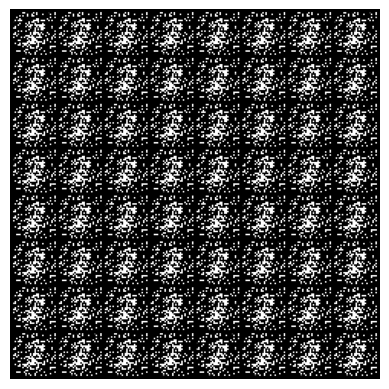

In [ ]:
visualize_plt_sample(generator, 64)

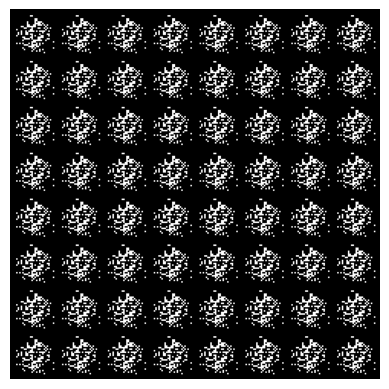

In [ ]:
visualize_plt_sample(generator_smooth, 64)

#### Тестирование DCGAN

In [ ]:
generator_dcgan = Generator_DCGAN(latent_dim).to(device)
discriminator_dcgan  = Discriminator_DCGAN().to(device)

loss_func = nn.BCELoss()

gen_optim_dcgan = torch.optim.Adam(generator_dcgan.parameters(), lr=learning_rate)
discr_optim_dcgan = torch.optim.Adam(discriminator_dcgan.parameters(), lr=learning_rate)

In [ ]:
load_model_state(generator_dcgan, "dcgan_gen_29", gen_optim_dcgan)
load_model_state(discriminator_dcgan, "dcgan_discr_29", discr_optim_dcgan)

In [ ]:
train_GAN(data_loader, generator_dcgan, discriminator_dcgan, gen_optim_dcgan, discr_optim_dcgan, loss_func, num_epochs, gen_title="dcgan_gen", discr_title="dcgan_discr", is_flatten=False)

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'Generator BCELoss',
              'type': 'scatter',
              'uid': '104ca1cc-d331-47ae-a84e-f7fa992f0428',
              'xaxis': 'x',
              'yaxis': 'y'},
             {'legendgroup': '2',
              'line': {'color': 'orange'},
              'name': 'Discriminator BCELoss',
              'type': 'scatter',
              'uid': '14d38e0e-79cf-432f-85cd-dfd5866dd418',
              'xaxis': 'x2',
              'yaxis': 'y2'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Generator Loss',
                                'x': 0.13333333333333333,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                   

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 25 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 26 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 27 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29 train:   0%|          | 0/938 [00:00<?, ?it/s]

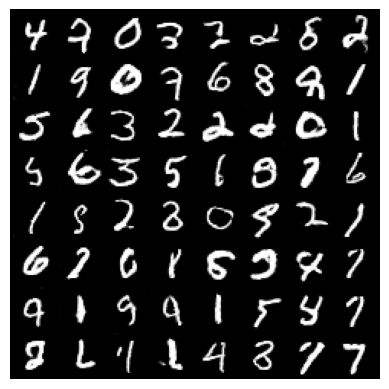

In [ ]:
visualize_plt_sample(generator_dcgan, False, 64)

### Контроль генерации через интерполяццию

In [ ]:
def generate_interpolated_images(generator, latent_dim, device, steps=10, is_flatten=False):
    generator.eval()

    z1 = torch.randn(1, latent_dim, device=device)
    z2 = torch.randn(1, latent_dim, device=device)

    interpolated_z = torch.stack([(1 - alpha) * z1 + alpha * z2 for alpha in torch.linspace(0, 1, steps)])
    interpolated_z = interpolated_z.squeeze(1)

    if is_flatten:
        interpolated_z = interpolated_z.view(steps, latent_dim)
    else:
        interpolated_z = interpolated_z.view(steps, latent_dim, 1, 1)

    with torch.no_grad():
        generated = generator(interpolated_z).cpu()
    if is_flatten:
        generated = generated.reshape(-1, 1, 28, 28)

    print(generated.shape)
    img_grid = make_grid(generated, nrow=int(np.sqrt(steps)), normalize=True)
    plt.imshow(img_grid.cpu().permute(1, 2, 0))
    plt.grid(False)
    plt.axis("off")
    plt.show()


torch.Size([64, 1, 28, 28])


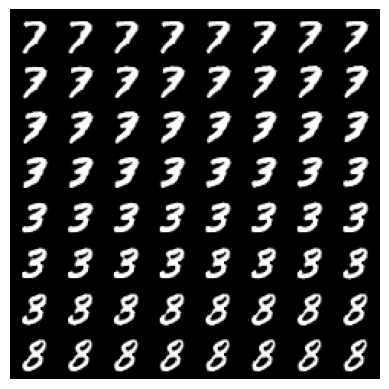

In [ ]:
generate_interpolated_images(generator_dcgan, latent_dim, steps=64, device=device)

torch.Size([64, 1, 28, 28])


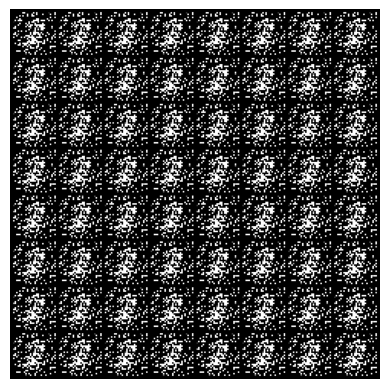

In [ ]:
generate_interpolated_images(generator, latent_dim, steps=64, device=device, is_flatten=True)

torch.Size([64, 1, 28, 28])


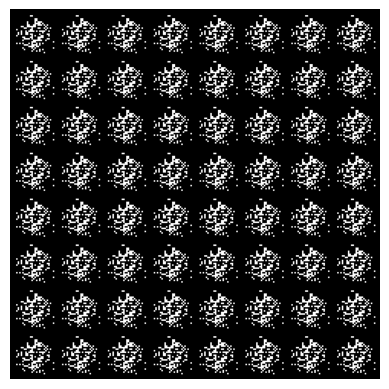

In [ ]:
generate_interpolated_images(generator_smooth, latent_dim, steps=64, device=device, is_flatten=True)

### CGAN

In [ ]:
class Generator_CGAN(nn.Module):
    def __init__(self, latent_size, num_classes):
        super().__init__()
        self.latent_dim = latent_size
        self.label_embedding = nn.Embedding(num_classes, num_classes)
        self.model = nn.Sequential(
            nn.ConvTranspose2d(latent_size + num_classes, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 3, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 3, 2, 1, output_padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 3, 2, 1, output_padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, labels):
        label_emb = self.label_embedding(labels)
        label_emb = label_emb.unsqueeze(2).unsqueeze(3)
        x = torch.cat([z, label_emb], 1)
        return self.model(x)


class Discriminator_CGAN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, 28*28)
        self.model = nn.Sequential(
            nn.Conv2d(2, 64, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, 4, 1, 0),
            nn.Flatten(),
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        label_emb = self.label_embedding(labels).view(labels.size(0), 1, 28, 28)
        x = torch.cat([img, label_emb], 1)  # Объединяем с метками
        return self.model(x)

In [ ]:
generator_cgan = Generator_CGAN(latent_dim, 10).to(device)
discriminator_cgan = Discriminator_CGAN(10).to(device)

criterion = nn.BCELoss()

g_optimizer = torch.optim.Adam(generator_cgan.parameters(), lr=learning_rate)
d_optimizer = torch.optim.Adam(discriminator_cgan.parameters(), lr=learning_rate)

In [ ]:
G_losses, D_losses = [], []

for epoch in tqdm(range(num_epochs)):
    for real_images, labels in tqdm(data_loader):
        real_images = real_images.to(device)
        labels = labels.to(device)
        batch_size = real_images.size(0)

        # Метки для обучения
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Обучение дискриминатора
        d_optimizer.zero_grad()
        outputs = discriminator_cgan(real_images, labels).view(-1, 1)
        d_loss_real = criterion(outputs, real_labels)
        d_loss_real.backward()

        z = torch.randn(batch_size, latent_dim, 1, 1).to(device)
        fake_images = generator_cgan(z, labels)
        outputs = discriminator_cgan(fake_images.detach(), labels).view(-1, 1)
        d_loss_fake = criterion(outputs, fake_labels)
        d_loss_fake.backward()
        d_optimizer.step()

        d_loss = d_loss_real + d_loss_fake

        # Обучение генератора
        g_optimizer.zero_grad()
        outputs = discriminator_cgan(fake_images, labels).view(-1, 1)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()
        g_optimizer.step()


    G_losses.append(g_loss.item())
    D_losses.append(d_loss.item())

    print(f"Epoch {epoch}, g_loss = {G_losses[-1]}, d_loss = {D_losses[-1]}")


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 0, g_loss = 7.990152359008789, d_loss = 0.0006332886405289173


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1, g_loss = 11.83607006072998, d_loss = 0.1573844999074936


...

Epoch 19, g_loss = 11.605086326599121, d_loss = 0.03639888018369675


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 20, g_loss = 5.680850028991699, d_loss = 0.13563522696495056


  0%|          | 0/938 [00:00<?, ?it/s]

KeyboardInterrupt: 

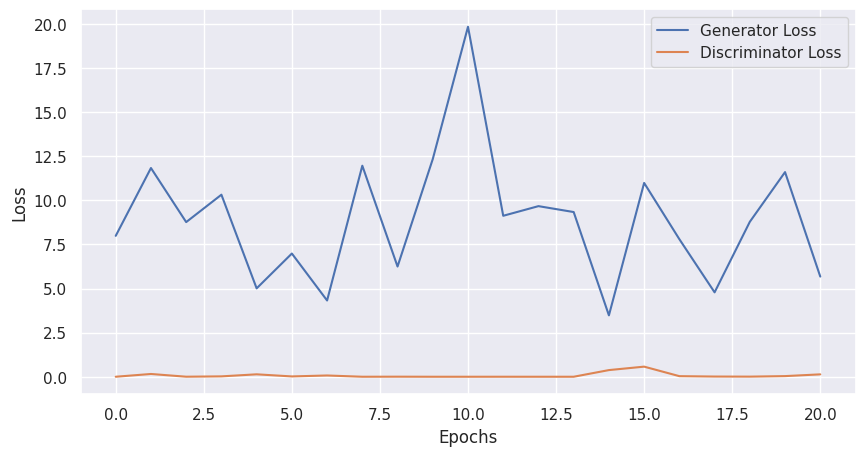

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(G_losses, label='Generator Loss')
plt.plot(D_losses, label='Discriminator Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

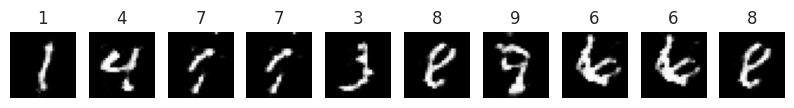

In [ ]:
# Генерация изображений
z = torch.randn(10, latent_dim, 1, 1).to(device)
labels = torch.randint(0, 10, (10,)).to(device)  # случайные метки для генерации
fake_images = generator_cgan(z, labels).cpu().detach()
fake_images = (fake_images + 1) / 2  # Обратное нормирование

# Выводим сгенерированные изображения с их метками
fig, axes = plt.subplots(1, 10, figsize=(10, 1.5))
for i in range(10):
    axes[i].imshow(fake_images[i][0], cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"{labels[i].item()}", fontsize=12)  # Добавляем метку в заголовок

plt.show()
